## **Notebook 01: Introduction to LangGraph - Building Your First Graph**

### **Setup**

In [ ]:
# Using uv (recommended)
# uv venv --python 3.12 && source .venv/bin/activate && uv pip install -e .

# Or traditional pip:
# pip install langgraph>=1.1.9 langchain-openai>=1.2.1

### **Step 1: Define the State Schema**


In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

import json

print("✅ Imports successful!")
print("📦 Ready to build your first graph!")

✅ Imports successful!
📦 Ready to build your first graph!


In [ ]:
from langgraph.graph import MessagesState  # ← new in 1.1.x

# Equivalent to:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
class State(TypedDict):
    """The state that will flow through our graph."""
    text: str

### **Step 2: Define Node Functions**

In [ ]:
def node_a(state: State) -> dict:
    """First node: appends 'a' to the text."""
    print("🔵 Node A executing...")
    return {"text": state["text"] + "a"}

def node_b(state: State) -> dict:
    """Second node: appends 'b' to the text."""
    print("🟢 Node B executing...")
    return {"text": state["text"] + "b"}

### **Step 3: Build the Graph**

In [ ]:
# Create a new graph with our State schema
graph = StateGraph(State)

# Add nodes to the graph
graph.add_node("node_a", node_a)
graph.add_node("node_b", node_b)

# Define the flow: START -> node_a -> node_b -> END
graph.add_edge(START, "node_a")
graph.add_edge("node_a", "node_b")
graph.add_edge("node_b", END)

print("✅ Graph structure defined!")

✅ Graph structure defined!


### **Step 4: Compile and Execute**

In [ ]:
import base64
from IPython.display import Image, display

app = graph.compile()
mermaid_text = app.get_graph().draw_mermaid()

# Encode the mermaid syntax as base64 and use mermaid.ink as an image source
graph_bytes  = mermaid_text.encode("utf-8")
base64_str   = base64.urlsafe_b64encode(graph_bytes).decode("utf-8")
url          = f"https://mermaid.ink/img/{base64_str}?theme=default"

display(Image(url=url))

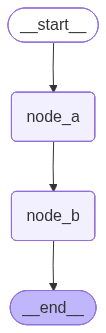

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(app.get_graph().draw_mermaid())

In [ ]:
# Run the graph with an initial state
initial_state = {"text": ""}
result = app.invoke(initial_state)

print("\n" + "="*50)
print("📊 Final Result:")
print(json.dumps(result, indent=2))
print("="*50)

🔵 Node A executing...
🟢 Node B executing...

📊 Final Result:
{
  "text": "ab"
}


### **Example 1: Text Processing Pipeline**


In [ ]:
import re

# Define a more complex state
class TextState(TypedDict):
    original: str      # Original text
    processed: str     # Processed text
    word_count: int    # Word count result

In [ ]:
# Node 1: Convert to lowercase
def to_lowercase(state: TextState) -> dict:
    """Convert text to lowercase."""
    print("🔄 Converting to lowercase...")
    lowercased = state["original"].lower()
    return {"processed": lowercased}

In [ ]:
# Node 2: Remove punctuation
def remove_punctuation(state: TextState) -> dict:
    """Remove all punctuation from text."""
    print("🔄 Removing punctuation...")
    cleaned = re.sub(r'[^\w\s]', '', state["processed"])
    return {"processed": cleaned}

In [ ]:
# Node 3: Count words
def count_words(state: TextState) -> dict:
    """Count the number of words."""
    print("🔄 Counting words...")
    words = state["processed"].split()
    count = len(words)
    return {"word_count": count}

In [ ]:
# Build the graph
text_graph = StateGraph(TextState)

text_graph.add_node("lowercase", to_lowercase)
text_graph.add_node("remove_punct", remove_punctuation)
text_graph.add_node("count", count_words)

text_graph.add_edge(START, "lowercase")
text_graph.add_edge("lowercase", "remove_punct")
text_graph.add_edge("remove_punct", "count")
text_graph.add_edge("count", END)

# Compile
text_app = text_graph.compile()

print("✅ Text processing pipeline ready!")

✅ Text processing pipeline ready!


In [ ]:
# Test the pipeline
test_text = "Hello, World! This is LangGraph. It's amazing!!"

result = text_app.invoke({
    "original": test_text,
    "processed": "",
    "word_count": 0
})

🔄 Converting to lowercase...
🔄 Removing punctuation...
🔄 Counting words...


In [ ]:
print("\n" + "="*60)
print("📝 Text Processing Results:")
print("="*60)
print(f"Original:  {result['original']}")
print(f"Processed: {result['processed']}")
print(f"Words:     {result['word_count']}")
print("="*60)


📝 Text Processing Results:
Original:  Hello, World! This is LangGraph. It's amazing!!
Processed: hello world this is langgraph its amazing
Words:     7


### **Example 2: Simple Calculator Chain**

In [ ]:
class CalcState(TypedDict):
    value: float      # Current value
    operations: list  # Log of operations performed

In [ ]:
def add_10(state: CalcState) -> dict:
    """Add 10 to the current value."""
    new_value = state["value"] + 10
    operations = state["operations"] + [f"Added 10: {state['value']} + 10 = {new_value}"]
    print(f"➕ Adding 10: {state['value']} → {new_value}")
    return {"value": new_value, "operations": operations}

In [ ]:
def multiply_by_2(state: CalcState) -> dict:
    """Multiply the current value by 2."""
    new_value = state["value"] * 2
    operations = state["operations"] + [f"Multiplied by 2: {state['value']} × 2 = {new_value}"]
    print(f"✖️  Multiplying by 2: {state['value']} → {new_value}")
    return {"value": new_value, "operations": operations}

In [ ]:
def subtract_5(state: CalcState) -> dict:
    """Subtract 5 from the current value."""
    new_value = state["value"] - 5
    operations = state["operations"] + [f"Subtracted 5: {state['value']} - 5 = {new_value}"]
    print(f"➖ Subtracting 5: {state['value']} → {new_value}")
    return {"value": new_value, "operations": operations}

In [ ]:
# Build calculator graph
calc_graph = StateGraph(CalcState)

calc_graph.add_node("add", add_10)
calc_graph.add_node("multiply", multiply_by_2)
calc_graph.add_node("subtract", subtract_5)

# Chain: START → add → multiply → subtract → END
calc_graph.add_edge(START, "add")
calc_graph.add_edge("add", "multiply")
calc_graph.add_edge("multiply", "subtract")
calc_graph.add_edge("subtract", END)


calc_app = calc_graph.compile()

print("✅ Calculator ready!")

✅ Calculator ready!


In [ ]:
# Test the calculator: (5 + 10) × 2 - 5 = ?
result = calc_app.invoke({
    "value": 5.0,
    "operations": []
})

print("\n" + "="*60)
print("🧮 Calculator Results:")
print("="*60)
print(f"Starting value: 5.0")
print(f"Final value: {result['value']}")
print("\nOperation Log:")
for op in result['operations']:
    print(f"  • {op}")
print("="*60)

➕ Adding 10: 5.0 → 15.0
✖️  Multiplying by 2: 15.0 → 30.0
➖ Subtracting 5: 30.0 → 25.0

🧮 Calculator Results:
Starting value: 5.0
Final value: 25.0

Operation Log:
  • Added 10: 5.0 + 10 = 15.0
  • Multiplied by 2: 15.0 × 2 = 30.0
  • Subtracted 5: 30.0 - 5 = 25.0
